# Reviewer A synthetic-practice assessment

## Technical summary

This notebook independently reads the code-generated practice audit and explains
what the first synthetic attempt demonstrates. It is a learning report only. It
does **not** assess formal reviewer calibration, authorize formal Mae Sai query
access, create labels, train a model, affect FPPS, or support a warning claim.

**Answer first:** the exported files are internally valid and reproducible, but
the attempt needs targeted remediation before any later readiness discussion.
The main learning gap is separating temporary flood from uncertain water change,
especially around vegetation, agriculture, timing differences, registration
artifacts, and mixed boundaries.


## Context and method

The upstream auditor already performs strict schema, identity, timestamp,
cell-count, checksum, score, and safety-flag validation. This notebook consumes
only that governed output, re-checks its summary self-hash, derives class metrics
from the 5 × 5 confusion matrix, and ranks cases for learning follow-up.

To rerun this notebook, set `FLOODGUARD_PRACTICE_ASSESSMENT_DIR` to a successful
audit directory before starting the kernel. No personal filesystem path is
embedded in the notebook.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

assessment_dir = Path(os.environ["FLOODGUARD_PRACTICE_ASSESSMENT_DIR"])
executed_at_utc = os.environ["FLOODGUARD_NOTEBOOK_EXECUTED_AT_UTC"]

required_files = {
    "summary": assessment_dir / "summary.json",
    "case_metrics": assessment_dir / "case_metrics.csv",
    "confusion_matrix": assessment_dir / "confusion_matrix.csv",
}
missing = [str(path.name) for path in required_files.values() if not path.is_file()]
assert not missing, f"Missing governed audit files: {missing}"

summary = json.loads(required_files["summary"].read_text(encoding="utf-8"))
case_metrics = pd.read_csv(required_files["case_metrics"])
confusion = pd.read_csv(required_files["confusion_matrix"])

assert summary["validation_status"] == "passed"
assert summary["integrity_issue_count"] == 0
assert summary["practice_only"] is True
assert summary["formal_review_authorized"] is False
assert summary["eligible_for_reviewer_calibration"] is False
assert summary["eligible_for_query_model_training"] is False
assert summary["eligible_for_fpps"] is False
assert summary["eligible_for_warning"] is False
assert len(case_metrics) == summary["summary_metrics"]["case_count"]
assert int(confusion["cell_count"].sum()) == summary["summary_metrics"]["cell_count"]

print(f"Loaded governed assessment at {executed_at_utc}.")
print(f"Cases: {len(case_metrics):,}; cells: {int(confusion['cell_count'].sum()):,}.")


Loaded governed assessment at 2026-07-12T14:01:18Z.
Cases: 20; cells: 20,480.


## Data integrity and safety boundary

In [2]:
hash_payload = dict(summary)
declared_summary_hash = hash_payload.pop("summary_sha256")
canonical = json.dumps(
    hash_payload,
    ensure_ascii=False,
    sort_keys=True,
    separators=(",", ":"),
).encode("utf-8")
recomputed_summary_hash = hashlib.sha256(canonical).hexdigest()
assert recomputed_summary_hash == declared_summary_hash

integrity_table = pd.DataFrame(
    [
        ("Audit validation", summary["validation_status"]),
        ("Integrity issues", summary["integrity_issue_count"]),
        ("Practice only", summary["practice_only"]),
        ("Real event queries used", summary["real_event_queries_used"]),
        ("Formal review authorized", summary["formal_review_authorized"]),
        ("Calibration eligibility", summary["eligible_for_reviewer_calibration"]),
        ("Model-training eligibility", summary["eligible_for_query_model_training"]),
        ("FPPS eligibility", summary["eligible_for_fpps"]),
        ("Warning eligibility", summary["eligible_for_warning"]),
        ("Summary self-hash", "verified"),
    ],
    columns=["check", "observed"],
)
integrity_table


,check,observed
0,Audit validation,passed
1,Integrity issues,0
2,Practice only,True
3,Real event queries used,False
4,Formal review authorized,False
5,Calibration eligibility,False
6,Model-training eligibility,False
7,FPPS eligibility,False
8,Warning eligibility,False
9,Summary self-hash,verified


## Result overview

In [3]:
metrics = summary["summary_metrics"]
overview = pd.DataFrame(
    [
        ("Cell accuracy", metrics["overall_accuracy"]),
        ("Temporary-flood precision", metrics["aggregate_temporary_flood_precision"]),
        ("Temporary-flood recall", metrics["aggregate_temporary_flood_recall"]),
        ("Temporary-flood Dice", metrics["aggregate_temporary_flood_dice"]),
        ("Flood-present case mean Dice", metrics["mean_flood_present_case_dice"]),
        ("Primary assessment match rate", metrics["primary_assessment_match_rate"]),
        ("All-eight-layers inspection rate", metrics["all_evidence_layers_viewed_case_count"] / metrics["case_count"]),
        ("Reasoning-note completion rate", metrics["reasoning_note_present_count"] / metrics["case_count"]),
    ],
    columns=["metric", "value"],
)
overview_display = overview.copy()
overview_display["value"] = overview_display["value"].map(lambda value: f"{value:.1%}")
overview_display


,metric,value
0,Cell accuracy,85.6%
1,Temporary-flood precision,42.6%
2,Temporary-flood recall,58.8%
3,Temporary-flood Dice,49.4%
4,Flood-present case mean Dice,66.6%
5,Primary assessment match rate,65.0%
6,All-eight-layers inspection rate,45.0%
7,Reasoning-note completion rate,0.0%


The overall cell accuracy is dominated by the large dry background.
Temporary-flood Dice, primary-assessment agreement, process completeness, and
class-specific confusions are more informative for the next learning decision.


In [4]:
label_order = (
    confusion[["truth_label_code", "truth_label_name"]]
    .drop_duplicates()
    .sort_values("truth_label_code")
)
class_rows = []
for row in label_order.itertuples(index=False):
    code = int(row.truth_label_code)
    name = str(row.truth_label_name)
    truth_total = int(confusion.loc[confusion.truth_label_code == code, "cell_count"].sum())
    predicted_total = int(confusion.loc[confusion.predicted_label_code == code, "cell_count"].sum())
    true_positive = int(
        confusion.loc[
            (confusion.truth_label_code == code)
            & (confusion.predicted_label_code == code),
            "cell_count",
        ].sum()
    )
    precision = true_positive / predicted_total if predicted_total else float("nan")
    recall = true_positive / truth_total if truth_total else float("nan")
    dice_denominator = truth_total + predicted_total
    dice = 2 * true_positive / dice_denominator if dice_denominator else float("nan")
    union = truth_total + predicted_total - true_positive
    iou = true_positive / union if union else float("nan")
    class_rows.append(
        {
            "label_code": code,
            "label_name": name,
            "truth_cells": truth_total,
            "predicted_cells": predicted_total,
            "precision": precision,
            "recall": recall,
            "dice": dice,
            "iou": iou,
        }
    )

class_metrics = pd.DataFrame(class_rows)
class_metrics_display = class_metrics.copy()
for metric_column in ["precision", "recall", "dice", "iou"]:
    class_metrics_display[metric_column] = class_metrics_display[metric_column].map(
        lambda value: f"{value:.1%}"
    )
class_metrics_display


,label_code,label_name,truth_cells,predicted_cells,precision,recall,dice,iou
0,0,dry_land,15851,16272,94.2%,96.7%,95.5%,91.3%
1,1,temporary_flood,1416,1955,42.6%,58.8%,49.4%,32.8%
2,2,permanent_or_preexisting_water,387,258,100.0%,66.7%,80.0%,66.7%
3,3,uncertain_water_change,1970,1226,38.6%,24.0%,29.6%,17.4%
4,4,unobservable_or_artifact,856,769,83.2%,74.8%,78.8%,65.0%


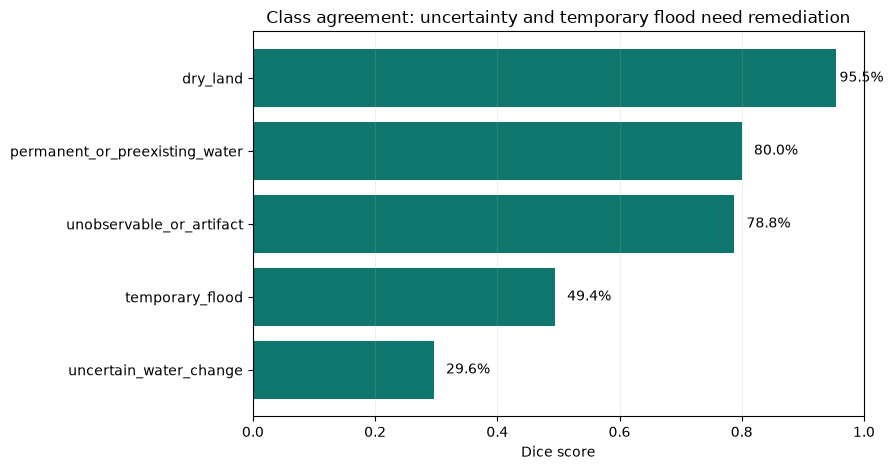

In [5]:
plot_data = class_metrics.sort_values("dice")
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(plot_data["label_name"], plot_data["dice"], color="#0f766e")
ax.set_xlim(0, 1)
ax.set_xlabel("Dice score")
ax.set_title("Class agreement: uncertainty and temporary flood need remediation")
ax.grid(axis="x", alpha=0.2)
for bar, value in zip(bars, plot_data["dice"], strict=True):
    ax.text(min(value + 0.02, 0.96), bar.get_y() + bar.get_height() / 2, f"{value:.1%}", va="center")
plt.tight_layout()
plt.show()


## Case-level remediation priorities

In [6]:
priority_columns = [
    "practice_case_id",
    "teaching_challenge",
    "selected_primary_assessment",
    "expected_primary_assessment",
    "primary_assessment_matches",
    "accuracy",
    "temporary_flood_dice",
    "evidence_layer_count",
    "reasoning_note_present",
    "confidence",
]
priority_cases = case_metrics.sort_values(
    ["accuracy", "temporary_flood_dice", "practice_case_id"]
)[priority_columns].head(10).copy()
priority_cases["accuracy"] = priority_cases["accuracy"].map(lambda value: f"{value:.1%}")
priority_cases["temporary_flood_dice"] = priority_cases["temporary_flood_dice"].map(
    lambda value: f"{value:.1%}"
)
priority_cases


,practice_case_id,teaching_challenge,selected_primary_assessment,expected_primary_assessment,primary_assessment_matches,accuracy,temporary_flood_dice,evidence_layer_count,reasoning_note_present,confidence
6,SYN-SAR-007,wet soil or agricultural change,uncertain_water_change,uncertain_water_change,True,0.0%,0.0%,8,False,medium
14,SYN-SAR-015,urban layover/double-bounce ambiguity,uncertain_water_change,uncertain_water_change,True,64.0%,100.0%,8,False,medium
16,SYN-SAR-017,agricultural field change,uncertain_water_change,uncertain_water_change,True,64.2%,0.0%,5,False,medium
10,SYN-SAR-011,mixed flood/dry boundary,uncertain_water_change,mixed_geometry,False,76.6%,0.0%,8,False,medium
9,SYN-SAR-010,temporal ambiguity,temporary_flood,uncertain_water_change,False,76.7%,0.0%,8,False,high
15,SYN-SAR-016,flooded vegetation with mixed response,uncertain_water_change,temporary_flood,False,81.0%,0.0%,7,False,high
8,SYN-SAR-009,pre/post misregistration edge,uncertain_water_change,unobservable_or_artifact,False,84.4%,100.0%,8,False,medium
5,SYN-SAR-006,flooded vegetation brightening,mixed_geometry,temporary_flood,False,85.4%,0.0%,8,False,medium
13,SYN-SAR-014,permanent water plus new flood,uncertain_water_change,mixed_geometry,False,87.4%,100.0%,5,False,medium
19,SYN-SAR-020,complete multiclass geometry,mixed_geometry,mixed_geometry,True,94.5%,100.0%,8,False,high


In [7]:
off_diagonal = confusion.loc[
    confusion.truth_label_code != confusion.predicted_label_code
].sort_values("cell_count", ascending=False)
off_diagonal.head(10)


,truth_label_code,truth_label_name,predicted_label_code,predicted_label_name,cell_count
15,3,uncertain_water_change,0,dry_land,883
16,3,uncertain_water_change,1,temporary_flood,614
8,1,temporary_flood,3,uncertain_water_change,583
1,0,dry_land,1,temporary_flood,508
23,4,unobservable_or_artifact,3,uncertain_water_change,160
14,2,permanent_or_preexisting_water,4,unobservable_or_artifact,129
20,4,unobservable_or_artifact,0,dry_land,56
3,0,dry_land,3,uncertain_water_change,10
4,0,dry_land,4,unobservable_or_artifact,0
2,0,dry_land,2,permanent_or_preexisting_water,0


## Takeaways

1. **The files are trustworthy as practice exports.** All governed integrity,
   checksum, timing, identity, score, and safety checks passed with zero issues.
2. **The attempt is not yet learning-complete.** Temporary-flood Dice is about
   49%, primary-scenario match is 65%, only 9 of 20 cases recorded all eight
   evidence layers, and no case contains a reasoning note.
3. **The key problem is semantic, not merely geometric.** The largest errors
   exchange uncertain water change with dry land or temporary flood, and exchange
   temporary flood with uncertain water change. This supports a targeted
   remediation exercise rather than generic repetition.
4. **Do not use the macro all-case flood Dice as the headline.** Empty-truth and
   empty-prediction cases score 1.0 and inflate that mean. Pooled flood Dice and
   the mean across truth-flood cases are the safer learning indicators.
5. **No formal gate moved.** The correct status remains
   `first_pass_complete_needs_targeted_remediation`.

## Next step

Complete the fresh, unseen 12-case synthetic remediation workbench. For every
case, explicitly visit all eight layers, paint all 1,024 cells, record a
grid-consistent primary assessment, select confidence, add an ambiguity reason
when using class 3 or 4, and write at least 20 non-whitespace reasoning
characters. Export the draft, session JSON, and cell CSV only after all 12 cases
are locked and revealed.

## Further questions after remediation

- Did flood-versus-uncertain Dice improve without simply overusing dry land?
- Are flooded vegetation, agriculture, temporal mismatch, misregistration, and
  permanent-water boundaries now distinguished consistently?
- Did the reviewer use all evidence layers and written reasoning on every case?
- Is a second unseen practice pass needed before Phase 5 orientation?

Formal calibration remains out of scope until the distinct human roles,
Reference Authority approvals, genuine unseen reserve, expert/adjudicated
reference, and calibration procedure exist.
